In [15]:
!pip install tensorflow keras --upgrade -q

In [16]:
# ========================== 1. IMPORTAI ==========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt

print("TensorFlow versija:", tf.__version__)

# ========================== 2. PARAMETRAI ==========================
SEED = 42

# Global seeds
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 12

DATA_DIR = "/home/arulipn/Amber_data/amber_cropped_224"   # ← pakeisk į savo kelią (naują 224x224 duomenų bazę)

# ========================== 3. DATA AUGMENTATION ==========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.20,
    fill_mode='reflect',                # reflect dažnai geriau nei nearest
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input  # jei naudoji VGG16
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# ========================== 4. VGG16 TRANSFER LEARNING ==========================
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Užšaldome bazinį modelį (pirmas etapas)
base_model.trainable = False

model = Sequential([
    base_model,

    # Global Average Pooling (geriau nei Flatten)
    GlobalAveragePooling2D(),

    # Klasifikavimo sluoksniai
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(NUM_CLASSES, activation='softmax')
])

# ========================== 5. KOMPILIACIJA ==========================
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ========================== 6. CALLBACKS ==========================
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_vgg16_amber.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# ========================== 7. MOKYMAS (1 etapas - frozen base) ==========================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ========================== 8. FINE-TUNING (2 etapas) ==========================
print("\n=== Pradedamas Fine-Tuning ===")

# Atšaldome kelis paskutinius VGG16 sluoksnius
base_model.trainable = True

# Užšaldome pirmus ~15 sluoksnių (VGG16 turi 19 sluoksnių su svoriais)
for layer in base_model.layers[:15]:
    layer.trainable = False

# Kompiliuojame su mažesniu learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-4),   # labai mažas lr
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tęsiame mokymą
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=callbacks
)

TensorFlow versija: 2.20.0
Found 1878 images belonging to 12 classes.
Found 465 images belonging to 12 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,881,996 (56.77 MB)

 Trainable params: 166,540 (650.55 KB)

 Non-trainable params: 14,715,456 (56.14 MB)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.2418 - loss: 2.6034 
Epoch 1: val_accuracy improved from None to 0.22151, saving model to best_vgg16_amber.keras

Epoch 1: finished saving model to best_vgg16_amber.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 24s 378ms/step - accuracy: 0.3062 - loss: 2.1404 - val_accuracy: 0.2215 - val_loss: 3.6571 - learning_rate: 0.0100
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.4232 - loss: 1.5424 
Epoch 2: val_accuracy did not improve from 0.22151
59/59 ━━━━━━━━━━━━━━━━━━━━ 21s 359ms/step - accuracy: 0.4414 - loss: 1.4634 - val_accuracy: 0.1892 - val_loss: 2.5123 - learning_rate: 0.0100
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.4750 - loss: 1.3798 
Epoch 3: val_accuracy improved from 0.22151 to 0.35914, saving model to best_vgg16_amber.keras

Epoch 3: finished saving model to best_vgg16_amber.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 22s 363ms/step - accuracy: 0.4675 - loss: 1.3638 - val_accuracy: 0.3591 - 

In [17]:
# 9. Galutinis modelis ant validation duomenų
# ────────────────────────────────────────────────────────────────

model.load_weights('best_vgg16_amber.keras')

val_loss, val_acc = model.evaluate(val_generator)
print(f"\nGeriausias modelis ant validation: loss = {val_loss:.4f}, accuracy = {val_acc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 273ms/step - accuracy: 0.7914 - loss: 0.5679

Geriausias modelis ant validation: loss = 0.5679, accuracy = 0.7914


15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 297ms/step


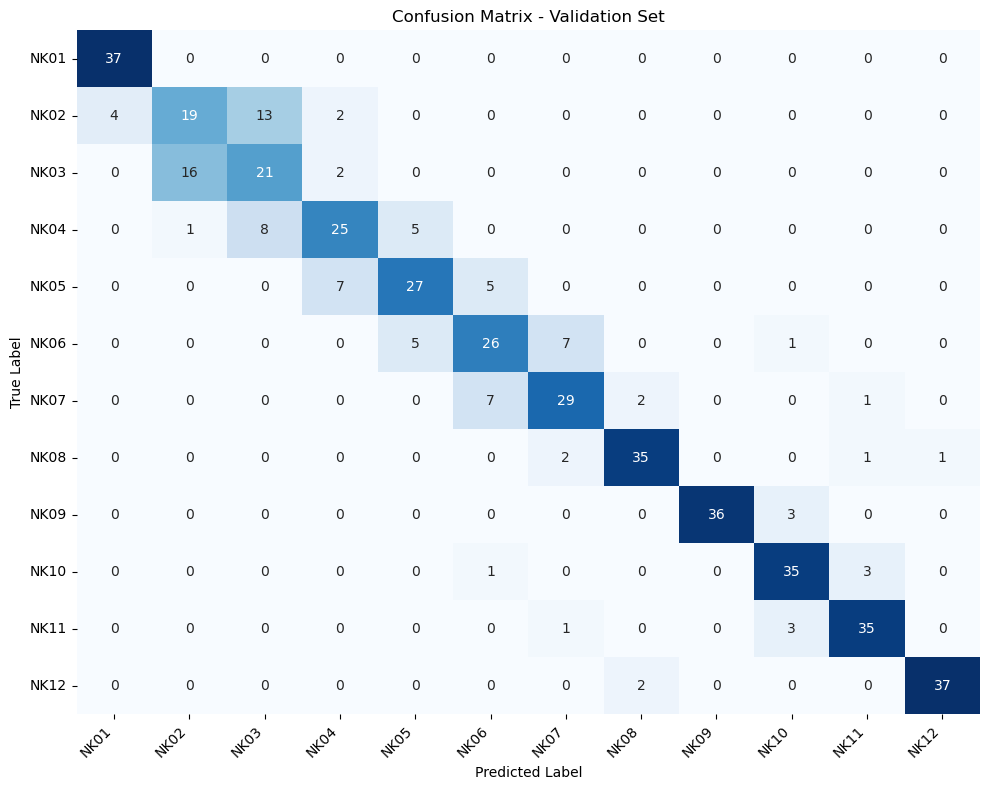

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions on validation set
y_pred_prob = model.predict(val_generator)          # shape: (n_samples, n_classes)
y_pred = np.argmax(y_pred_prob, axis=1)             # predicted class indices

# 2. Get true labels from generator
y_true = val_generator.classes[val_generator.index_array]  # true class indices

# Make sure lengths match (sometimes generator shuffles)
# If using shuffle=False in val_generator → y_true = val_generator.classes

# 3. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot with seaborn (beautiful & readable)
class_names = list(val_generator.class_indices.keys())  # e.g. ['nk01', 'nk02', ..., 'nk12']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=False)

plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

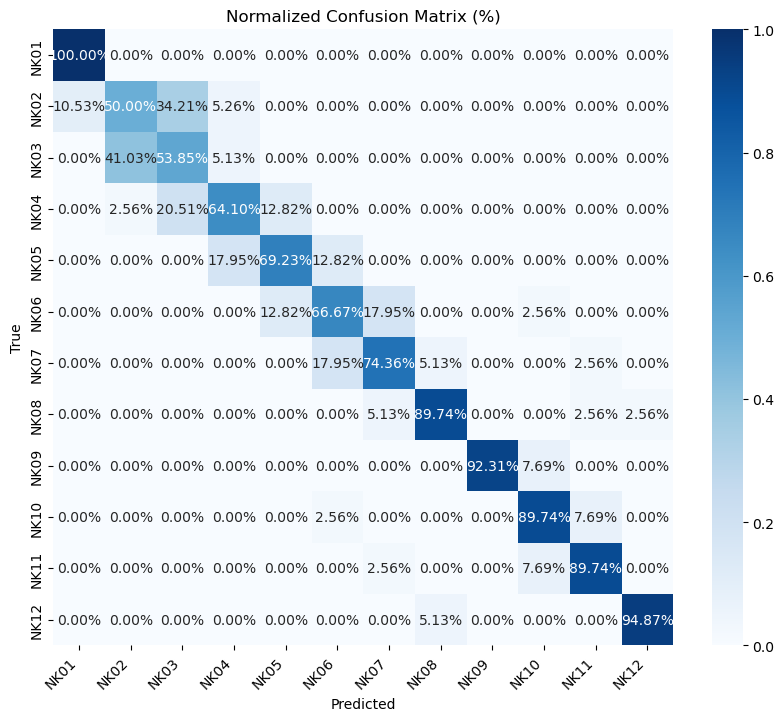

In [19]:
# Normalized CM (row-wise = true class distribution)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.show()

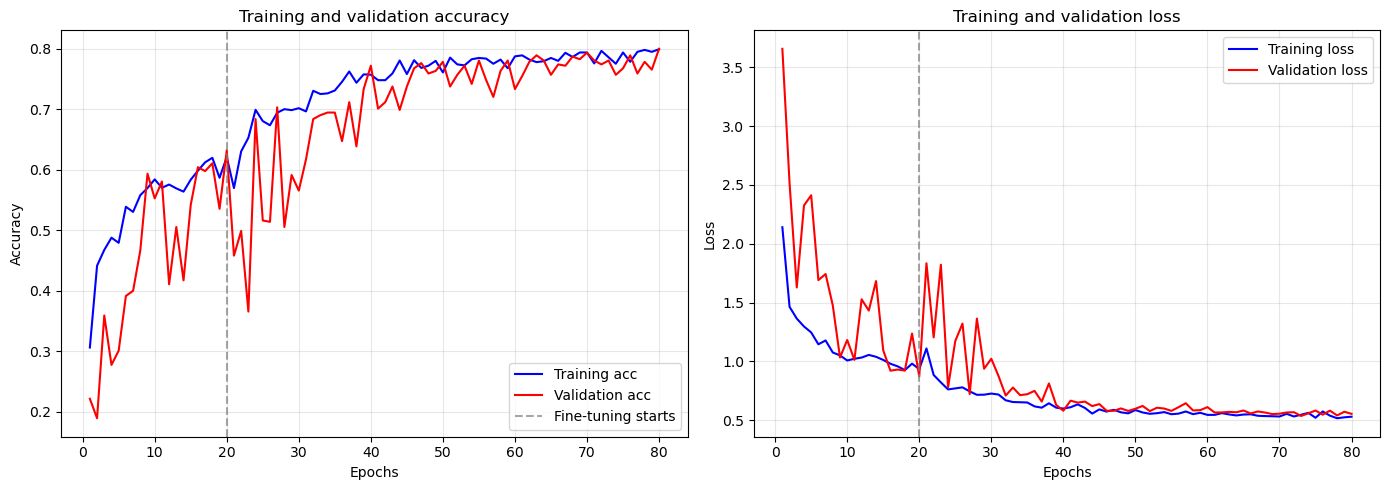

In [20]:
import matplotlib.pyplot as plt

# Combine histories
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Create epoch numbers (continuous)
epochs = range(1, len(acc) + 1)

# Find the epoch where fine-tuning started
fine_tune_start = len(history.history['accuracy'])

# Plot Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training acc')
plt.plot(epochs, val_acc, 'r-', label='Validation acc')
plt.axvline(x=fine_tune_start, color='gray', linestyle='--', alpha=0.7, 
            label='Fine-tuning starts')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training loss')
plt.plot(epochs, val_loss, 'r-', label='Validation loss')
plt.axvline(x=fine_tune_start, color='gray', linestyle='--', alpha=0.7)
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()